In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/super-market-sales/supermarket_sales.xlsx


In [51]:
data = pd.read_excel('/kaggle/input/super-market-sales/supermarket_sales.xlsx')
data.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,886-18-2897,A,Yangon,Normal,Female,Food_and_beverages,56.56,5,14.140,296.940,3/22/2019,19:06:00,Credit card,282.80,4.761905,14.140,4.5
996,745-74-0715,A,Yangon,Normal,Male,Electronic_accessories,58.03,2,5.803,121.863,2019-10-03 00:00:00,20:46:00,Ewallet,116.06,4.761905,5.803,8.8
997,727-02-1313,A,Yangon,Member,Male,Food_and_beverages,31.84,1,1.592,33.432,2019-09-02 00:00:00,13:22:00,Cash,31.84,4.761905,1.592,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home_and_lifestyle,65.82,1,3.291,69.111,2/22/2019,15:33:00,Cash,65.82,4.761905,3.291,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion_accessories,88.34,7,30.919,649.299,2/18/2019,13:28:00,Cash,618.38,4.761905,30.919,6.6


In [52]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Mandalay,Member,Female,Food_and_beverages,54.84,3,8.226,172.746,2/20/2019,13:27:00,Credit card,164.52,4.761905,8.226,5.9
1,351-62-0822,B,Mandalay,Member,Female,Fashion_accessories,14.48,4,2.896,60.816,2019-06-02 00:00:00,18:07:00,Ewallet,57.92,4.761905,2.896,4.5
2,529-56-3974,B,Mandalay,Member,Male,Electronic_accessories,25.51,4,5.102,107.142,2019-09-03 00:00:00,17:03:00,Cash,102.04,4.761905,5.102,6.8
3,299-46-1805,B,Mandalay,Member,Female,Sports_and_travel,93.72,6,28.116,590.436,1/15/2019,16:19:00,Cash,562.32,4.761905,28.116,4.5
4,319-50-3348,B,Mandalay,Normal,Female,Home_and_lifestyle,40.30,2,4.030,84.630,2019-11-03 00:00:00,15:30:00,Ewallet,80.60,4.761905,4.030,4.4


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [54]:
data.describe(include='object')

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,849-09-3807,A,Yangon,Member,Female,Fashion_accessories,2019-07-02 00:00:00,14:42:00,Ewallet
freq,1,340,340,501,501,178,20,7,345


In [55]:
data.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [56]:
data.nunique()

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

# Data Wrangling 

In [57]:
data['datetime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'].astype(str), format='mixed')
data[['Date', 'Time', 'datetime']].head()

,Date,Time,datetime
0,2/20/2019,13:27:00,2019-02-20 13:27:00
1,2019-06-02 00:00:00,18:07:00,2019-06-02 18:07:00
2,2019-09-03 00:00:00,17:03:00,2019-09-03 17:03:00
3,1/15/2019,16:19:00,2019-01-15 16:19:00
4,2019-11-03 00:00:00,15:30:00,2019-11-03 15:30:00


In [58]:
data['month'] = data['datetime'].dt.month
data['date'] = data['datetime'].dt.day
# data['hour'] = data['datetime'].dt.hour

# https://www.statology.org/pandas-day-of-week/
data['day_of_week'] = data['datetime'].dt.weekday
data['day_names'] = data['datetime'].dt.day_name()

data[['Date', 'Time','datetime', 'month', 'date', 'day_of_week', 'day_names']].head()

,Date,Time,datetime,month,date,day_of_week,day_names
0,2/20/2019,13:27:00,2019-02-20 13:27:00,2,20,2,Wednesday
1,2019-06-02 00:00:00,18:07:00,2019-06-02 18:07:00,6,2,6,Sunday
2,2019-09-03 00:00:00,17:03:00,2019-09-03 17:03:00,9,3,1,Tuesday
3,1/15/2019,16:19:00,2019-01-15 16:19:00,1,15,1,Tuesday
4,2019-11-03 00:00:00,15:30:00,2019-11-03 15:30:00,11,3,6,Sunday


In [59]:
data[['Date', 'Time', 'datetime', 'month', 'date', 'day_of_week', 'day_names']].nunique()

Date            89
Time           506
datetime       994
month           12
date            22
day_of_week      7
day_names        7
dtype: int64

There isn't any duplicated rows in this dataset.

In [60]:
duplicated_rows = data[data.duplicated()]
duplicated_rows

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Payment,cogs,gross margin percentage,gross income,Rating,datetime,month,date,day_of_week,day_names


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   object        
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [62]:
index = data.columns
index

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'datetime', 'month', 'date', 'day_of_week', 'day_names'],
      dtype='object')

# EDA

In [63]:
data.sort_values(['Branch', 'Total']).head().T

,873,755,987,728,687
Invoice ID,308-39-1707,490-29-1201,593-08-5916,802-43-8934,382-03-4532
Branch,A,A,A,A,A
City,Yangon,Yangon,Yangon,Yangon,Yangon
Customer type,Normal,Normal,Normal,Normal,Member
Gender,Female,Female,Female,Male,Female
Product line,Fashion_accessories,Sports_and_travel,Fashion_accessories,Home_and_lifestyle,Health_and_beauty
Unit price,12.09,15.34,15.5,18.28,18.33
Quantity,1,1,1,1,1
Tax 5%,0.6045,0.767,0.775,0.914,0.9165
Total,12.6945,16.107,16.275,19.194,19.2465


In [64]:
def describe_categorical_values(df):
    for col in df.columns:
        print(f"\nAttribute: {col}")
        
        # Extract unique values
        unique_vals = df[col].dropna().unique()
        
        # Sort values (works for strings, numbers, categoricals)
        try:
            sorted_vals = np.sort(unique_vals)
        except:
            # fallback for mixed types
            sorted_vals = sorted(unique_vals, key=lambda x: str(x))
        
        print("Unique values (sorted):")
        for v in sorted_vals:
            print(f"  - {v}")

cat_variables = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment', 'day_names']
describe_categorical_values(data[cat_variables])



Attribute: Branch
Unique values (sorted):
  - A
  - B
  - C

Attribute: City
Unique values (sorted):
  - Mandalay
  - Naypyitaw
  - Yangon

Attribute: Customer type
Unique values (sorted):
  - Member
  - Normal

Attribute: Gender
Unique values (sorted):
  - Female
  - Male

Attribute: Product line
Unique values (sorted):
  - Electronic_accessories
  - Fashion_accessories
  - Food_and_beverages
  - Health_and_beauty
  - Home_and_lifestyle
  - Sports_and_travel

Attribute: Payment
Unique values (sorted):
  - Cash
  - Credit card
  - Ewallet

Attribute: day_names
Unique values (sorted):
  - Friday
  - Monday
  - Saturday
  - Sunday
  - Thursday
  - Tuesday
  - Wednesday


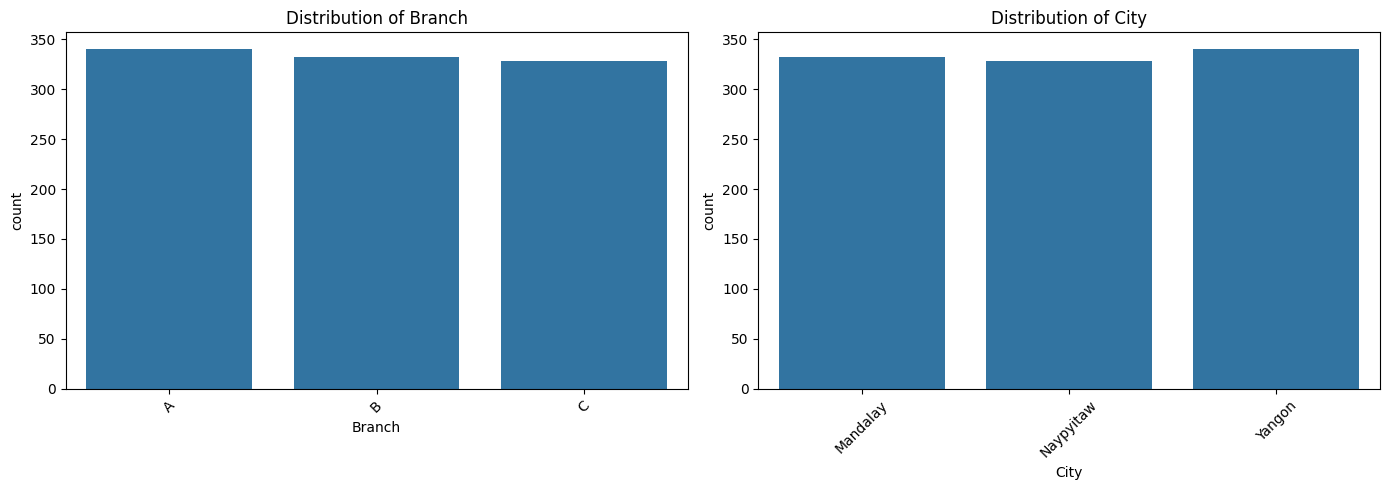

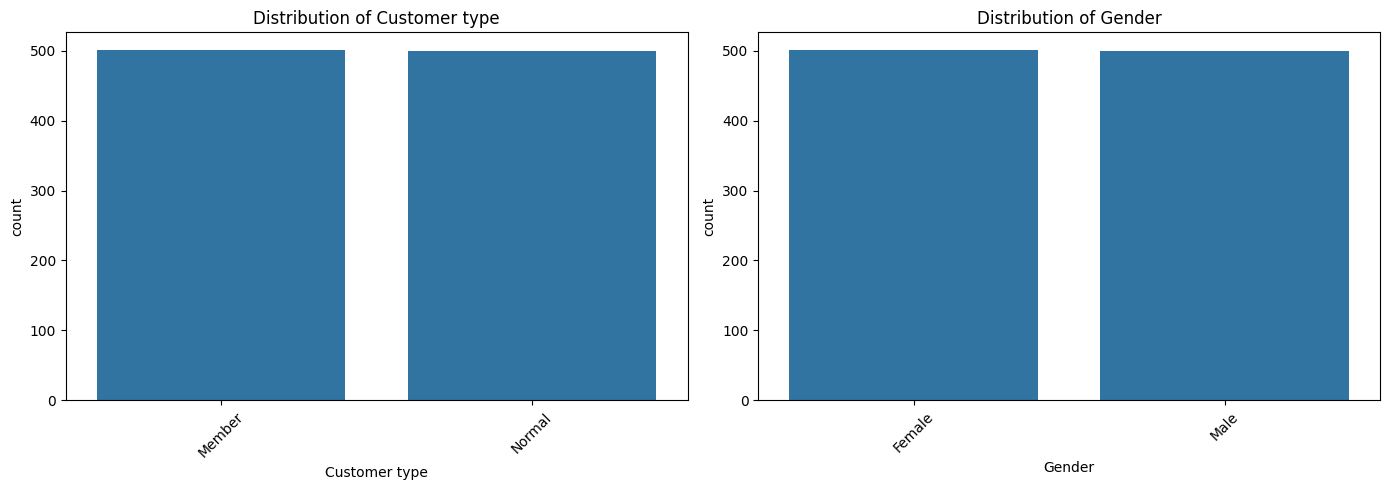

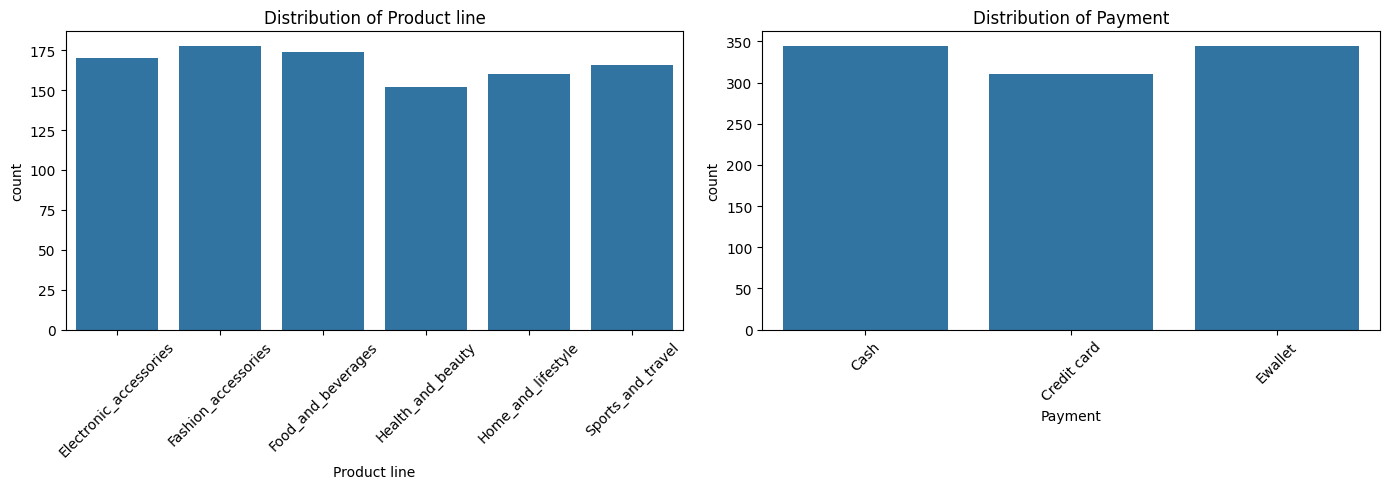

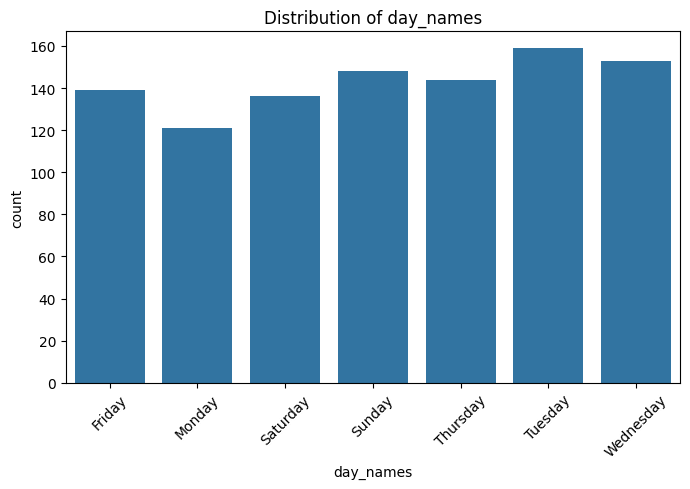

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_categorical_pairs(df):
    # Identify categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Loop through columns in pairs
    for i in range(0, len(cat_cols), 2):
        col1 = cat_cols[i]
        col2 = cat_cols[i+1] if i+1 < len(cat_cols) else None

        # Create subplot layout
        if col2:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        else:
            fig, axes = plt.subplots(1, 1, figsize=(7, 5))
            axes = [axes]

        # Plot first column
        sns.countplot(
            x=df[col1],
            ax=axes[0],
            order=sorted(df[col1].dropna().unique())
        )
        axes[0].set_title(f"Distribution of {col1}")
        axes[0].tick_params(axis='x', rotation=45)

        # Plot second column if exists
        if col2:
            sns.countplot(
                x=df[col2],
                ax=axes[1],
                order=sorted(df[col2].dropna().unique())
            )
            axes[1].set_title(f"Distribution of {col2}")
            axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

plot_all_categorical_pairs(data[cat_variables])

Correlation Matrix:
                         Unit price  Quantity    Tax 5%     Total      cogs  \
Unit price                 1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity                   0.010778  1.000000  0.705510  0.705510  0.705510   
Tax 5%                     0.633962  0.705510  1.000000  1.000000  1.000000   
Total                      0.633962  0.705510  1.000000  1.000000  1.000000   
cogs                       0.633962  0.705510  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.633962  0.705510  1.000000  1.000000  1.000000   
Rating                    -0.008778 -0.015815 -0.036442 -0.036442 -0.036442   

                         gross margin percentage  gross income    Rating  
Unit price                                   NaN      0.633962 -0.008778  
Quantity                                     NaN      0.705510 -0.015815  
Tax 5%                                     

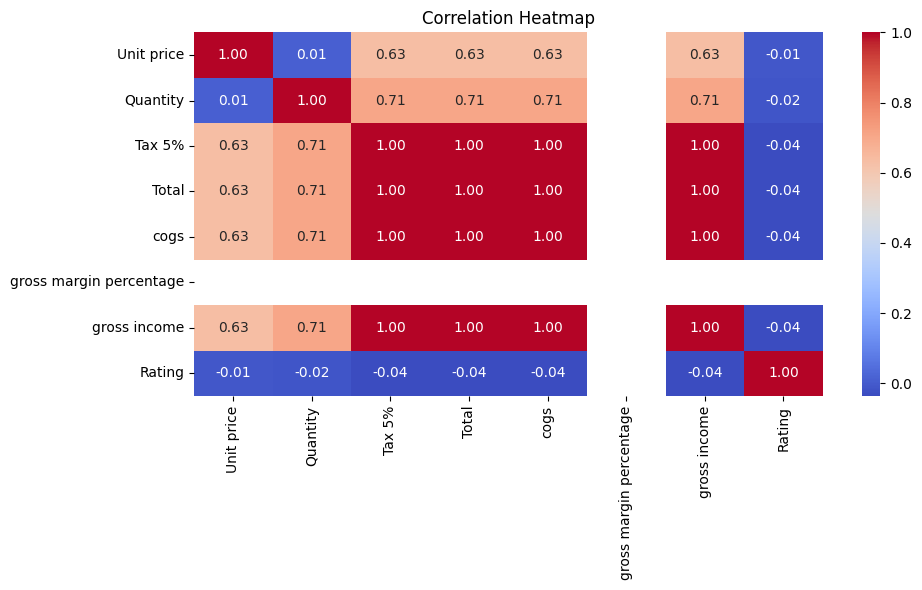

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def correlation_analysis(df):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64'])

    if numeric_df.empty:
        print("No numeric columns available for correlation analysis.")
        return

    # Compute correlation matrix
    corr_matrix = numeric_df.corr()

    print("Correlation Matrix:")
    print(corr_matrix)

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


correlation_analysis(data)


In [67]:
print(f'Number of unique value in gross marging percentage: ', data['gross margin percentage'].nunique())
print(f'Unique value for gross margin percentage: ', data['gross margin percentage'].unique())

Number of unique value in gross marging percentage:  1
Unique value for gross margin percentage:  [4.76190476]


From the viewpoint of numerical variables, it's seems that there is a rather strong positive correlation between calculation associated attributes / columns in this dataset, besides `Rating`.
For example, both `Unit Price` and `Quantity` showed a rather strong correlation reading. At the same time, `Total`, `Tax 5%`, `cogs`, and `gross income` are showing *1.00* correlation with each other.

There's one exception field named `gross margin percentage` detected, it acted as a constant throughout this dataset.

In [68]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


def cramers_v_matrix(df):
    # Select categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    n = len(cat_cols)

    # Create empty matrix
    result = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

    # Compute Cramér's V for each pair
    for col1 in cat_cols:
        for col2 in cat_cols:
            confusion_matrix = pd.crosstab(df[col1], df[col2])
            result.loc[col1, col2] = cramers_v(confusion_matrix)

    return result

cramers_v_corr = cramers_v_matrix(data)
print(cramers_v_corr)


               Invoice ID    Branch      City  Customer type    Gender  \
Invoice ID            1.0  1.000000  1.000000       1.000000  1.000000   
Branch                1.0  1.000000  1.000000       0.020465  0.059430   
City                  1.0  1.000000  1.000000       0.020465  0.059430   
Customer type         1.0  0.020465  0.020465       0.998000  0.037996   
Gender                1.0  0.059430  0.059430       0.037996  0.998000   
Product line          1.0  0.076024  0.076024       0.057663  0.075792   
Date                  1.0  0.288123  0.288123       0.291889  0.272040   
Time                  1.0  0.699129  0.699129       0.700080  0.699372   
Payment               1.0  0.040618  0.040618       0.072229  0.054311   
day_names             1.0  0.073693  0.073693       0.079591  0.071796   

               Product line      Date      Time   Payment  day_names  
Invoice ID         1.000000  1.000000  1.000000  1.000000   1.000000  
Branch             0.076024  0.288123  0.69

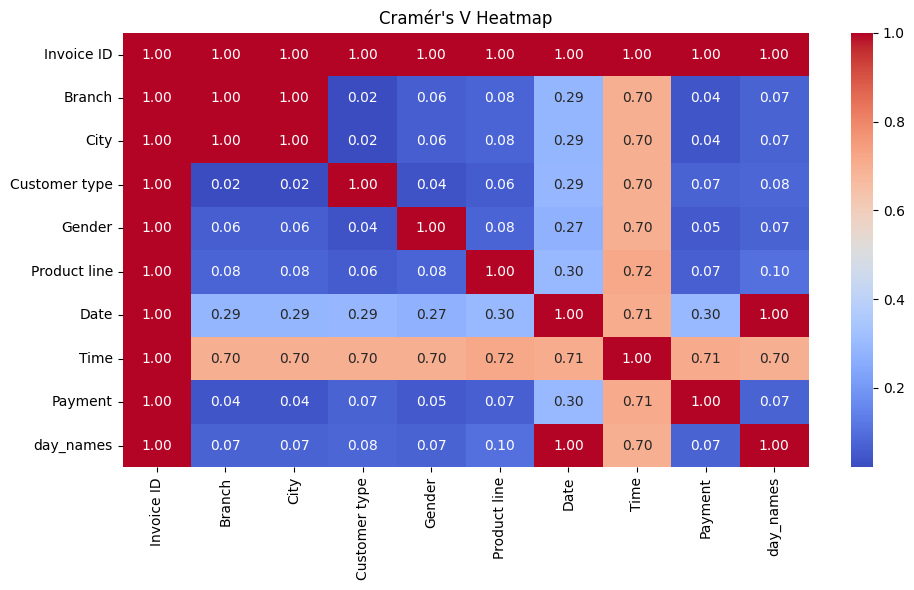

In [69]:
# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cramers_v_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap")
plt.tight_layout()
plt.show()


[](http://)From the viewpoint of categorical variables, it seems that `Branch` and `City` is showing *1.00* as its' correlation reading. Then, `Time` shows a rather strong positive correlation with all other variables, such as: 
- Customer Type
- Gender
- Product Line
- Date
- Payment
- day_names

Such trends occurs potentially due to the existance of operation hours of physical super market store. 

In [89]:
import duckdb as dd

duck_df = dd.sql("SELECT * FROM data")

In [90]:
dd.sql("SELECT * FROM duck_df TABLESAMPLE 1 ROWS;").show()

┌─────────────┬─────────┬──────────┬───────────────┬─────────┬─────────────────────┬────────────┬──────────┬─────────┬──────────┬───────────┬──────────┬─────────────┬────────┬─────────────────────────┬──────────────┬────────┬──────────┬───────┬────────┬─────────────┬───────────┐
│ Invoice ID  │ Branch  │   City   │ Customer type │ Gender  │    Product line     │ Unit price │ Quantity │ Tax 5%  │  Total   │   Date    │   Time   │   Payment   │  cogs  │ gross margin percentage │ gross income │ Rating │ datetime │ month │ date_1 │ day_of_week │ day_names │
│   varchar   │ varchar │ varchar  │    varchar    │ varchar │       varchar       │   double   │  int64   │ double  │  double  │  varchar  │   time   │   varchar   │ double │         double          │    double    │ double │  int32   │ int32 │ int32  │    int32    │  varchar  │
├─────────────┼─────────┼──────────┼───────────────┼─────────┼─────────────────────┼────────────┼──────────┼─────────┼──────────┼───────────┼──────────┼────────

# Archive / To be Reviewed

In [ ]:
data.to_csv("output_v2.csv", index=True)

print("Data written to output_v2.csv")

In [79]:
import numpy as np

def correlation_ratio(categories, values):
    # Remove missing values
    mask = ~np.isnan(values)
    categories = categories[mask]
    values = values[mask]

    # Overall mean
    grand_mean = values.mean()

    # Between-group variability
    ss_between = 0
    for cat in np.unique(categories):
        group_vals = values[categories == cat]
        ss_between += len(group_vals) * (group_vals.mean() - grand_mean) ** 2

    # Total variability
    ss_total = ((values - grand_mean) ** 2).sum()

    # η = sqrt(SS_between / SS_total)
    return np.sqrt(ss_between / ss_total) if ss_total != 0 else 0


def eta_matrix(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    result = pd.DataFrame(index=cat_cols, columns=num_cols, dtype=float)

    for cat in cat_cols:
        for num in num_cols:
            result.loc[cat, num] = correlation_ratio(df[cat].values, df[num].values)

    return result


eta_corr = eta_matrix(data.loc[ : , data.columns != 'datetime'])
print(eta_corr)


TypeError: '<' not supported between instances of 'datetime.datetime' and 'str'

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(eta_corr, annot=True, cmap='viridis', vmin=0, vmax=1)
plt.title("Correlation Ratio (η) — Categorical → Numeric")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# -------------------------
# Pearson (numeric ↔ numeric)
# -------------------------
def pearson_corr(df):
    return df.corr()
    

# -------------------------
# Cramér’s V (categorical ↔ categorical)
# -------------------------
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


def cramers_v_matrix(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    result = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for col1 in cat_cols:
        for col2 in cat_cols:
            cm = pd.crosstab(df[col1], df[col2])
            result.loc[col1, col2] = cramers_v(cm)

    return result


# -------------------------
# Correlation ratio η (categorical → numeric)
# -------------------------
def correlation_ratio(categories, values):
    mask = ~np.isnan(values)
    categories = categories[mask]
    values = values[mask]

    grand_mean = values.mean()
    ss_between = 0

    for cat in np.unique(categories):
        group_vals = values[categories == cat]
        ss_between += len(group_vals) * (group_vals.mean() - grand_mean) ** 2

    ss_total = ((values - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total != 0 else 0


def eta_matrix(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    result = pd.DataFrame(index=cat_cols, columns=num_cols, dtype=float)

    for cat in cat_cols:
        for num in num_cols:
            result.loc[cat, num] = correlation_ratio(df[cat].values, df[num].values)

    return result

In [ ]:
def mixed_correlation(df):
    # Identify columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    # Compute individual matrices
    pearson = pearson_corr(df[num_cols])
    cramers = cramers_v_matrix(df)
    eta = eta_matrix(df)

    # Create full matrix
    all_cols = list(num_cols) + list(cat_cols)
    full = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

    # Fill numeric ↔ numeric (Pearson)
    for i in num_cols:
        for j in num_cols:
            full.loc[i, j] = pearson.loc[i, j]

    # Fill categorical ↔ categorical (Cramér’s V)
    for i in cat_cols:
        for j in cat_cols:
            full.loc[i, j] = cramers.loc[i, j]

    # Fill categorical → numeric (η)
    for cat in cat_cols:
        for num in num_cols:
            full.loc[cat, num] = eta.loc[cat, num]
            full.loc[num, cat] = eta.loc[cat, num]  # symmetric for display

    return full

In [ ]:
mixed_corr = mixed_correlation(data)
mixed_corr

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(mixed_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Unified Mixed-Type Correlation Matrix\n(Pearson + Cramér’s V + η)")
plt.tight_layout()
plt.show()